In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error #MAE
from matplotlib.lines import Line2D
import warnings   # `do not disturbe` mode
warnings.filterwarnings('ignore')

In [2]:
# ! pip install -i https://pypi.tuna.tsinghua.edu.cn/simple scikit-learn

#### 分析训练集与测试集结果

In [3]:

data = pd.read_csv(r"E:\1\Predictionstrain_test_predRP.csv")
print(type(data))
data.head(3)

<class 'pandas.core.frame.DataFrame'>


,dt_train,gpr_train,knn_train,krr_train,lasso_train,lgbm_train,nn_train,rf_train,svr_train,xgb_train,...,gpr_predE,knn_predE,krr_predE,lasso_predE,lgbm_predE,nn_predE,rf_predE,svr_predE,xgb_predE,sr_predE
0,0.590667,0.502531,0.606,0.551571,0.493833,0.587003,0.587428,0.594331,0.511114,0.600993,...,0.891934,0.769764,0.858899,0.847316,0.822760,0.784329,0.851378,0.882819,0.832969,0.832969
1,0.325250,0.410949,0.334,0.367154,0.402043,0.344443,0.326187,0.334823,0.416560,0.331429,...,1.180486,1.059543,1.126252,1.169054,1.094047,1.217461,1.155640,1.192839,1.055733,1.055733
2,0.372667,0.490854,0.374,0.456442,0.478943,0.394805,0.386745,0.377210,0.491979,0.374923,...,1.126932,1.117978,1.111040,1.126617,1.056926,1.143854,1.071809,1.129632,1.047002,1.047002


In [4]:

data1 = pd.read_csv(r"E:\1\Evaluate_ResultsRP.csv")
data1 = data1.drop(data1.index[-1])
print(type(data1))
mae_sorted_test = data1.sort_values(by=['MAE_test'])
rmse_sorted_test = data1.sort_values(by=['RMSE_test']) 
mae_sorted_pred = data1.sort_values(by=['MAE_pred'])
rmse_sorted_pred = data1.sort_values(by=['RMSE_pred'])
mae_sorted_test.head()

<class 'pandas.core.frame.DataFrame'>


,Algorithm,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,MAE_pred,RMSE_pred,R2_pred
8,SVR,0.512594,0.728520,1.030869,1.306817,0.710054,0.757546,3.181396,3.553232,-273.961774
7,RF,0.266314,0.752908,0.454597,1.271076,0.943615,0.770626,3.747481,4.137899,-371.893565
6,NN,0.663488,0.765487,1.089739,1.286374,0.675992,0.765072,2.655674,2.895172,-181.546654
9,XGB,0.295356,0.815062,0.439575,1.339504,0.947280,0.745265,3.066635,3.619271,-284.277464
1,GPR,0.564047,0.821790,0.900095,1.456297,0.778951,0.698907,3.305937,3.735436,-302.883914


<class 'numpy.ndarray'>
MAE: 0.058


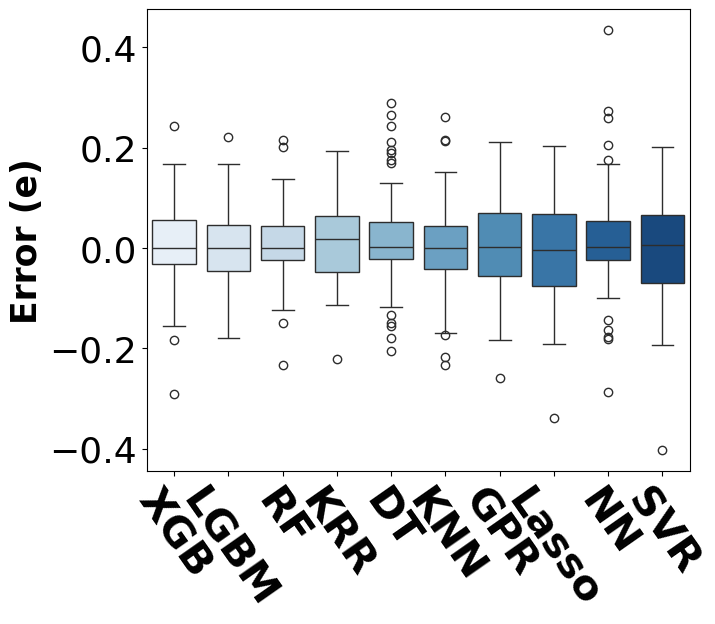

In [5]:

train_error = data[[ 'xgb_trainE', 'lgbm_trainE', 'rf_trainE', 'krr_trainE', 'dt_trainE', 'knn_trainE', 'gpr_trainE', 'lasso_trainE', 'nn_trainE', 'svr_trainE']].values
test_error = data[[ 'xgb_testE', 'lgbm_testE', 'rf_testE', 'krr_testE', 'dt_testE', 'knn_testE', 'gpr_testE', 'lasso_testE', 'nn_testE', 'svr_testE']].values
#method = mae_sorted_test['Algorithm'].tolist()
method = [ 'XGB','LGBM', 'RF','KRR','DT','KNN', 'GPR','Lasso', 'NN','SVR'  ]
print(type(train_error))
y_pred_test = data[['sr_test']].values
y_test = data[['y_test']].values


y_pred_test = y_pred_test[~np.isnan(y_pred_test).any(axis=1),:]
y_test = y_test[~np.isnan(y_test).any(axis=1),:]

MAE = mean_absolute_error(y_test, y_pred_test)
print("MAE: %.3f" % MAE)


#sns.violinplot(data=data1)
fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=test_error, palette='Blues')
plt.xticks(range(10), method, fontsize=30, fontweight='bold', rotation=-55,ha="center")
plt.yticks(fontsize=26)
#plt.ylim(-0.34,0.22)
plt.ylabel('Error (e)', fontsize=25, fontweight='bold')


plt.show()


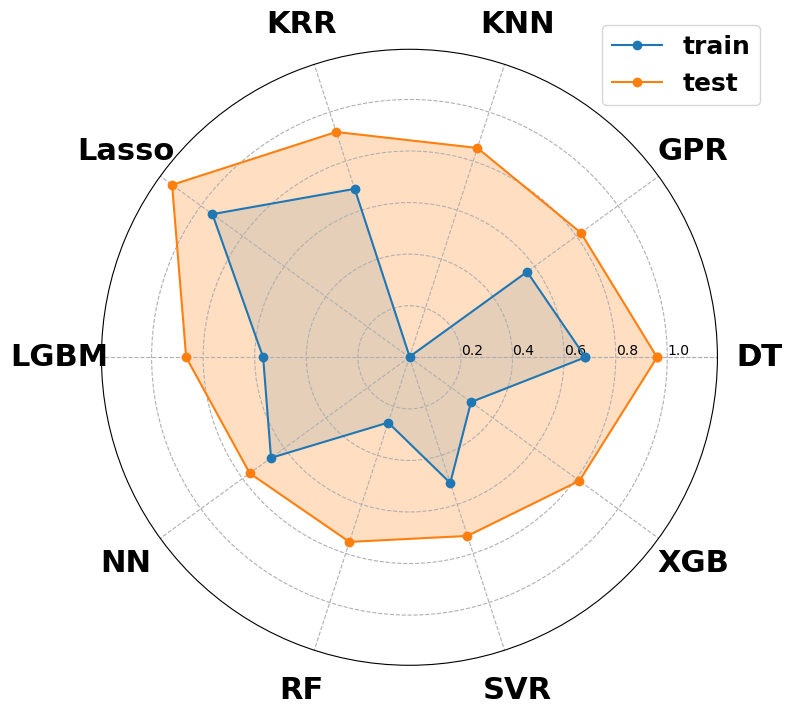

In [ ]:

df = pd.read_csv(r"E:\1\Evaluate_ResultsRP.csv")
df = df.drop(df.index[-1]) 
#df = df.sort_values(by=['MAE_test'])
data1 = df['MAE_train'].values
data2 = df['MAE_test'].values
#print(data)
methods = [ 'DT', 'GPR', 'KNN', 'KRR', 'Lasso', 'LGBM', 'NN', 'RF', 'SVR', 'XGB', ] 


num_vars = len(data1)
data1 = np.concatenate((data1, [data1[0]])) 
data2 = np.concatenate((data2, [data2[0]]))
methods = np.concatenate((methods, [methods[0]]))
angles = [n / float(num_vars) * 2 * 3.14159265359 for n in range(num_vars)] 
angles = np.concatenate((angles, [angles[0]]))

angle_step = 2 * np.pi / num_vars


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, data1, linestyle='-', marker='o', label='train')
ax.fill(angles, data1, alpha=0.15) 

ax.plot(angles, data2, linestyle='-', marker='o', label='test')
ax.fill(angles, data2, alpha=0.25)  


#ax.set_title('Radar Chart', size=20, y=1.1)
ax.set_xticks(np.arange(0, 2*np.pi, angle_step))
ax.set_xticks(angles)
ax.set_xticklabels(methods, fontsize=22, fontweight='bold')  
ax.yaxis.set_label_coords(0, 0.1)  
ax.set_rlabel_position(0)
ax.tick_params(axis='x', which='major', labelsize=22, pad=20) 

line1 = Line2D([0], [0], color='C0', linestyle='-', marker='o', label='train')
line2 = Line2D([0], [0], color='C1', linestyle='-',marker='o', label='test')

ax.legend(handles=[line1, line2], ncol=1, bbox_to_anchor=(1.09, 1.06), frameon=True, prop={'weight': 'bold', 'size': 18})

ax.xaxis.grid(linestyle='--')
ax.yaxis.grid(linestyle='--')


plt.show()


[1.16102004 0.90009542 0.03053328 1.07412538 1.46244003 1.02642828
 1.08973918 0.45459741 1.03086922 0.439575  ]


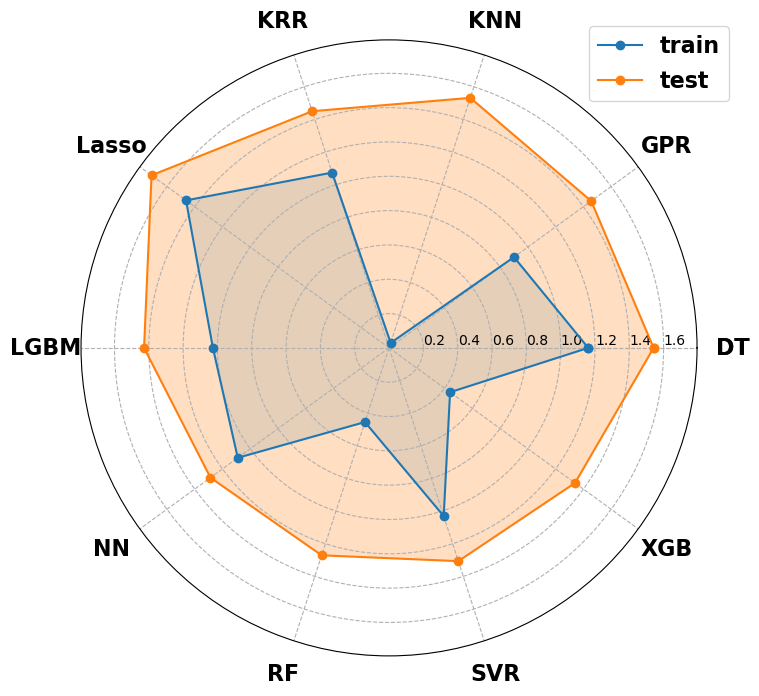

In [7]:

df = pd.read_csv(r"E:\1\Evaluate_ResultsRP.csv")
df = df.drop(df.index[-1]) 

data1 = df['RMSE_train'].values
data2 = df['RMSE_test'].values
print(data1)
methods = [ 'DT', 'GPR', 'KNN', 'KRR', 'Lasso', 'LGBM', 'NN', 'RF', 'SVR', 'XGB', ] 


num_vars = len(data1)
data1 = np.concatenate((data1, [data1[0]])) 
data2 = np.concatenate((data2, [data2[0]]))
methods = np.concatenate((methods, [methods[0]]))
angles = [n / float(num_vars) * 2 * 3.14159265359 for n in range(num_vars)] 
angles = np.concatenate((angles, [angles[0]]))

angle_step = 2 * np.pi / num_vars


fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, data1, linestyle='-', marker='o', label='train')
ax.fill(angles, data1, alpha=0.15)  

ax.plot(angles, data2, linestyle='-', marker='o', label='test')
ax.fill(angles, data2, alpha=0.25)  


#ax.set_title('Radar Chart', size=20, y=1.1)
ax.set_xticks(np.arange(0, 2*np.pi, angle_step))
ax.set_xticks(angles)
ax.set_xticklabels(methods, fontsize=16, fontweight='bold')  
ax.yaxis.set_label_coords(0, 0.1)  
ax.set_rlabel_position(0)
ax.tick_params(axis='x', which='major', labelsize=16, pad=15) 


line1 = Line2D([0], [0], color='C0', linestyle='-', marker='o', label='train')
line2 = Line2D([0], [0], color='C1', linestyle='-',marker='o', label='test')

ax.legend(handles=[line1, line2], ncol=1, bbox_to_anchor=(1.07, 1.04), frameon=True, prop={'weight': 'bold', 'size': 16})

ax.xaxis.grid(linestyle='--')
ax.yaxis.grid(linestyle='--')


plt.show()


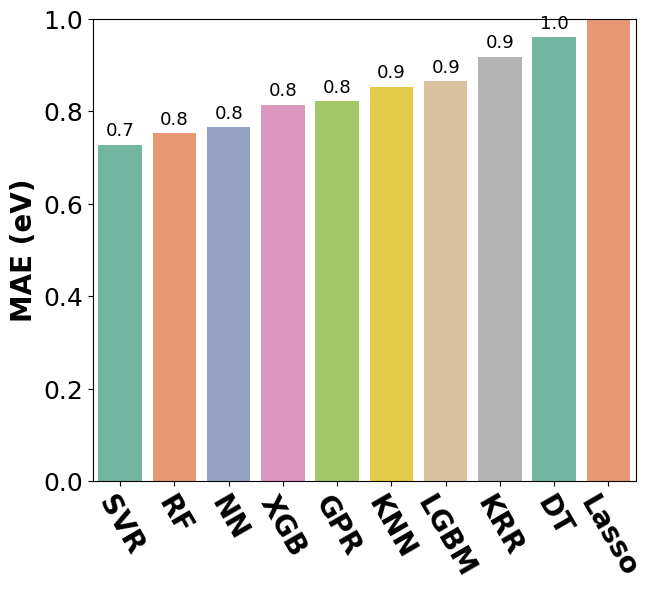

In [8]:

fig, ax = plt.subplots(figsize=(7, 6))
# sns.set(style="whitegrid")
sns.barplot(x='Algorithm', y='MAE_test', data=mae_sorted_test, palette='Set2')
plt.xticks(fontsize=20, fontweight='bold', rotation=-60)
plt.yticks(fontsize=18)
plt.xlabel('')
plt.ylabel('MAE (eV)', fontsize=20, fontweight='bold')
plt.ylim(0,1)


for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 10), fontsize=13,
                textcoords = 'offset points')

plt.show()


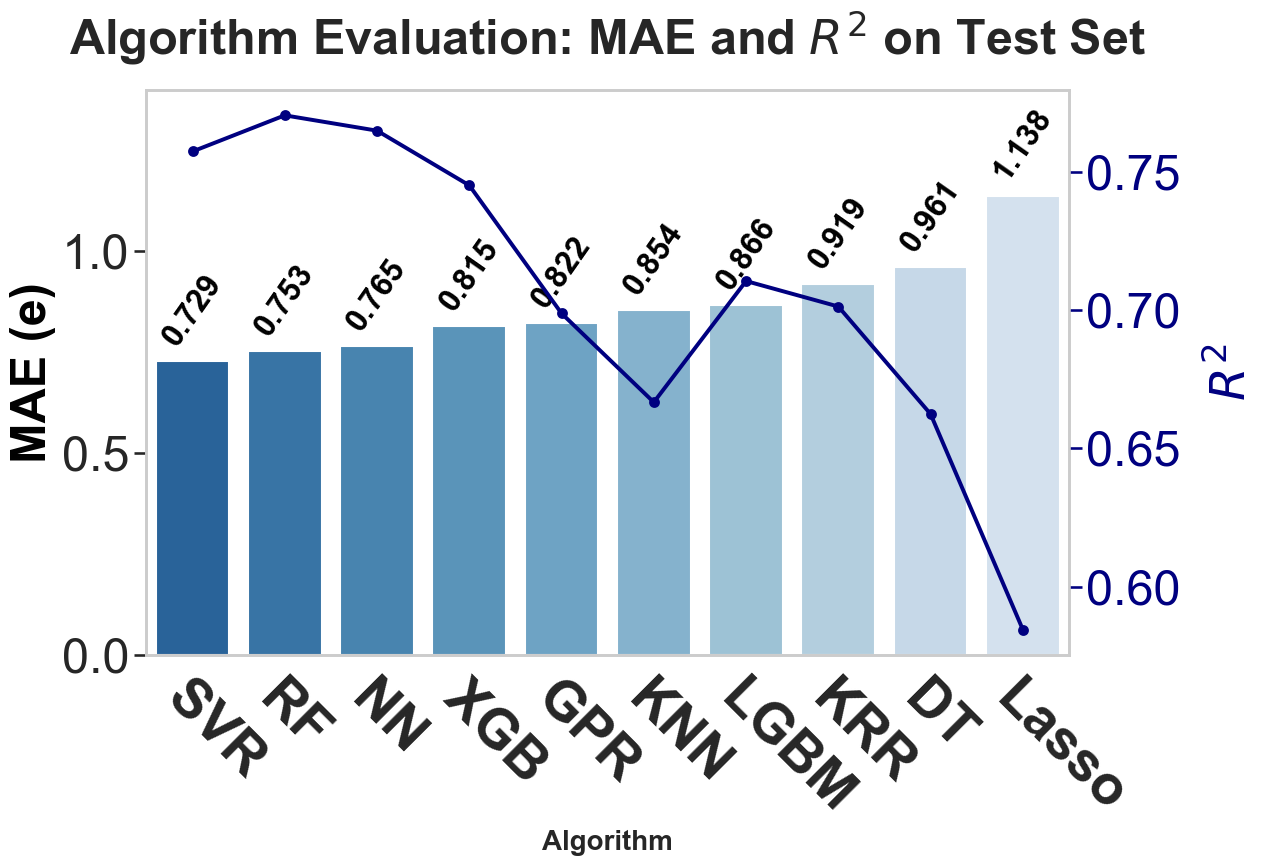

In [9]:

rmse_sorted_test = rmse_sorted_test.sort_values(by='MAE_test', ascending=True)



sns.set_theme(style="whitegrid", context="talk")


fig, ax1 = plt.subplots(figsize=(13, 9))



n_algorithms = len(rmse_sorted_test['Algorithm'])
start_color = 0.8  
end_color = 0.2    
colors = plt.cm.Blues(np.linspace(start_color, end_color, n_algorithms))
sns.barplot(x='Algorithm', y='MAE_test', data=rmse_sorted_test, palette=colors, ax=ax1)


ax1.grid(False) 


ax1.set_xlabel('Algorithm', fontsize=20, fontweight='bold')
ax1.set_ylabel('MAE (e)', fontsize=35, fontweight='bold', color='black')


plt.xticks(fontsize=40, fontweight='bold', rotation=-45, ha='left', rotation_mode='anchor')

ax1.tick_params(axis='y', labelsize=35)
ax1.set_ylim(0, 1.4) 


for p in ax1.patches:
    height = p.get_height()
    
    ax1.annotate(format(height, '.3f'),
                 (p.get_x() + p.get_width() / 2., height),
                rotation=55,
                 ha='center', va='bottom', 
                 xytext=(0, 7), # offset vertically
                 textcoords='offset points',
                 fontsize=23, fontweight='bold', color='black')


ax2 = ax1.twinx()


ax2.grid(False) 


sns.pointplot(x='Algorithm', y='R2_test', data=rmse_sorted_test, ax=ax2,
              linestyles='-', markers='o', color='navy', scale=0.7)


ax2.set_ylabel(r'$R^{2}$', fontsize=35, fontweight='bold', color='navy', labelpad=20)
ax2.tick_params(axis='y', labelsize=35, colors='navy') # 将 R2 的刻度颜色也设置为 navy


plt.title('Algorithm Evaluation: MAE and $R^{2}$ on Test Set', fontsize=35, fontweight='bold', pad=25)
plt.tight_layout() 


plt.show()

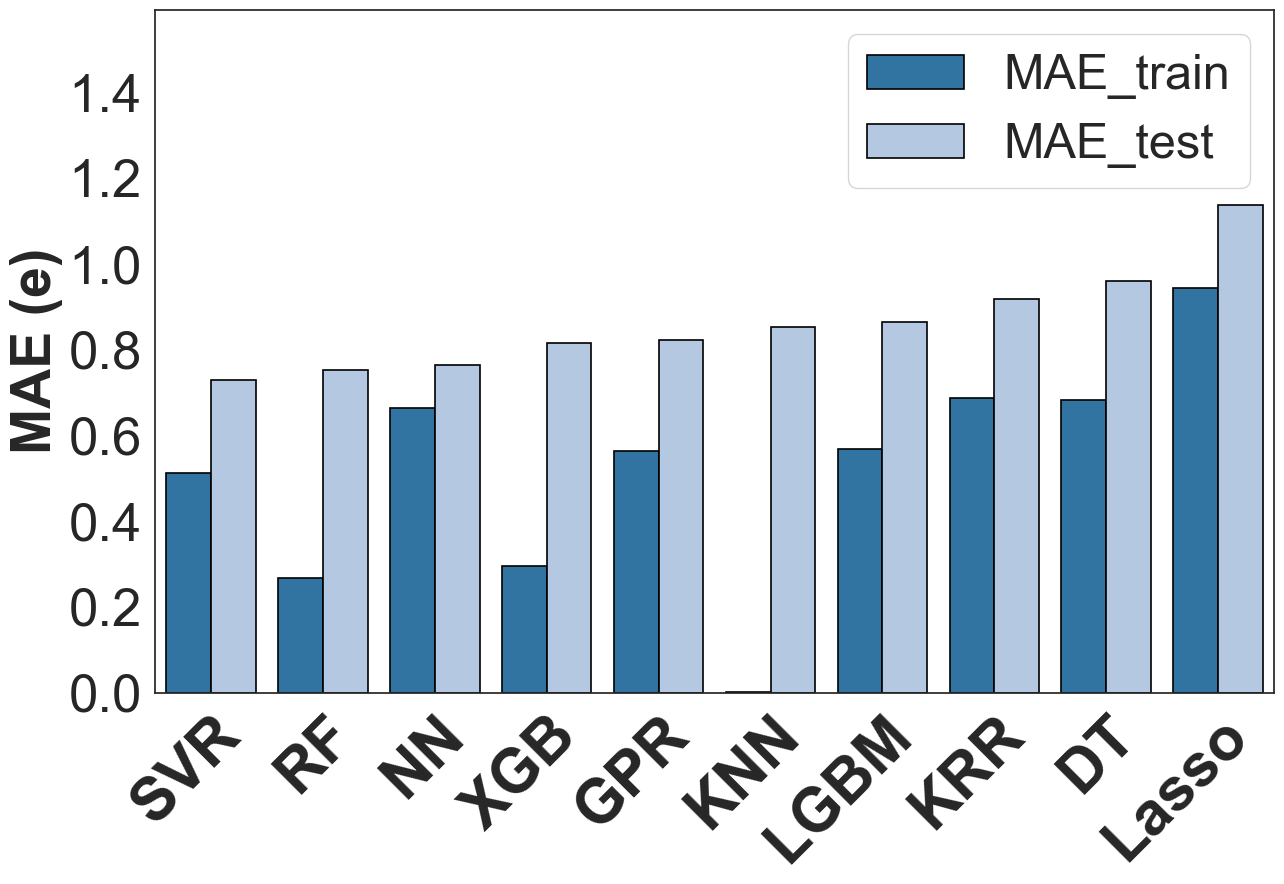

In [10]:

df_new = mae_sorted_test.melt(
    id_vars=['Algorithm'], 
    value_vars=['MAE_train', 'MAE_test'],
    var_name='Dataset', 
    value_name='MAE'
)


sns.set_theme(style="white") 
fig, ax = plt.subplots(figsize=(13, 9)) 


container = sns.barplot(
    x='Algorithm', 
    y='MAE', 
    hue='Dataset', 
    data=df_new, 
    palette=['#1F77B4', '#AEC7E8'], 
    edgecolor='black',
    linewidth=1.2
)


plt.xticks(
    fontsize=44, 
    fontweight='bold', 
    rotation=45, 
    ha='right', 
    rotation_mode='anchor'
) 

plt.yticks(fontsize=38)
plt.xlabel('', fontsize=55)
plt.ylabel('MAE (e)', fontsize=40, fontweight='bold')


max_val = df_new['MAE'].max()
plt.ylim(0, max_val * 1.4) 

plt.legend(title=None, fontsize=35, loc='upper right', frameon=True)


#sns.despine()
plt.tight_layout()

plt.show()